In [2]:
import pandas as pd

from matplotlib import pyplot as plt
import matplotlib.lines as mlines
import os

# seq_would_ee table

In [10]:
def get_would_ee_table(input_dir, policies):
    would_ee_but_stay = []
    would_not_ee_but_ee = []
    for policy in policies:
        for file in os.listdir(input_dir):
            if file.endswith(".csv") and policy in file:
                df = pd.read_csv(os.path.join(input_dir, file))
                num_ee_tokens = df['num_ee_tokens'][0]
                num_no_ee_tokens = df['num_no_ee_tokens'][0]
                would_ee = df['num_seq_would_ee_but_stay'][0]
                would_not_ee = df['num_seq_would_not_ee_but_ee'][0]

                would_ee_but_stay.append(would_ee / num_no_ee_tokens)
                would_not_ee_but_ee.append(would_not_ee / num_ee_tokens)

                print(f"Policy: {policy}, would_ee: {would_ee}, would_not_ee: {would_not_ee}, num_ee_tokens: {num_ee_tokens}, num_no_ee_tokens: {num_no_ee_tokens}")
    
    df = pd.DataFrame({
        'policy': policies,
        'would_ee_but_stay': would_ee_but_stay,
        'would_not_ee_but_ee': would_not_ee_but_ee
    })
    return df




In [11]:
policies = ["lazy", "median", "eager"]
get_would_ee_table("benchmarks/req_500_batch_4", policies)


Policy: lazy, would_ee: 22695, would_not_ee: 0, num_ee_tokens: 700, num_no_ee_tokens: 76469
Policy: median, would_ee: 19530, would_not_ee: 1183, num_ee_tokens: 5304, num_no_ee_tokens: 84343
Policy: eager, would_ee: 0, would_not_ee: 32757, num_ee_tokens: 126290, num_no_ee_tokens: 1008


,policy,would_ee_but_stay,would_not_ee_but_ee
0,lazy,0.296787,0.000000
1,median,0.231554,0.223039
2,eager,0.000000,0.259379


In [12]:
policies = ["lazy", "median", "eager"]
get_would_ee_table("benchmarks/req_500_batch_8", policies)


Policy: lazy, would_ee: 18089, would_not_ee: 0, num_ee_tokens: 12, num_no_ee_tokens: 56243
Policy: median, would_ee: 14561, would_not_ee: 949, num_ee_tokens: 2704, num_no_ee_tokens: 55129
Policy: eager, would_ee: 0, would_not_ee: 21677, num_ee_tokens: 63392, num_no_ee_tokens: 489


,policy,would_ee_but_stay,would_not_ee_but_ee
0,lazy,0.321622,0.000000
1,median,0.264126,0.350962
2,eager,0.000000,0.341952


In [4]:
policies = ["ee_nobatch", "off","eager", "lazy", "average", "rebatching"]
throughputs = []
precisions = []
recalls = []
fmeasures = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_fmeasure = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
precisions.append(avg_precision)
recalls.append(avg_recall)
fmeasures.append(avg_fmeasure)

for policy in policies[1:]:
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_fmeasure = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    precisions.append(avg_precision)
    recalls.append(avg_recall)
    fmeasures.append(avg_fmeasure)
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "precision": precisions,
    "recall": recalls,
    "fmeasure": fmeasures
})
df

,policy,throughput,precision,recall,fmeasure
0,ee_nobatch,112.404562,0.397218,0.218205,0.267738
1,off,69.853830,0.407214,0.241450,0.288385
2,eager,86.979928,0.044958,0.051632,0.045983
3,lazy,70.640574,0.413359,0.261426,0.304854
4,average,69.879729,0.395855,0.233908,0.279433
5,rebatching,83.106299,0.408882,0.237617,0.285724


In [9]:
policies = ["ee_nobatch", "off","eager", "lazy", "average", "rebatching"]
throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

for policy in policies[1:]:
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})
df

,policy,throughput,ROUGE-L,num_ee_tokens,num_no_ee_tokens,avg_conf_score,avg_conf_score_ee
0,ee_nobatch,26.552540,0.120703,32306,7970,0.908029,0.985430
1,off,72.612111,0.288385,0,1,0.757795,0.000000
2,eager,94.451514,0.028740,25432,169,0.919896,0.925298
3,lazy,73.143975,0.279157,444,16681,0.732171,0.952019
4,average,75.331483,0.279129,2344,16529,0.707134,0.903871
5,rebatching,81.450985,0.117615,14756,5145,0.792330,0.982013


In [6]:
policies = ["ee_nobatch", "off","eager", "lazy", "average", "rebatching"]
throughputs = []
rouge_scores = []
tpot = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []


ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

for policy in policies[1:]:
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "TPOT": tpot,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})
df

,policy,throughput,TPOT,ROUGE-L,num_ee_tokens,num_no_ee_tokens,avg_conf_score,avg_conf_score_ee
0,ee_nobatch,22.907277,0.042516,0.264900,8967,19312,0.793823,0.997913
1,off,69.853830,0.013548,0.270852,0,1,0.757795,0.000000
2,eager,86.979928,0.010960,0.074339,23904,865,0.908041,0.930441
3,lazy,70.640574,0.013431,0.270852,12,17041,0.764786,0.998544
4,average,69.879729,0.013535,0.293690,48,15765,0.752424,0.992550
5,rebatching,71.713645,0.013192,0.256510,4137,12119,0.667377,0.998350


In [15]:
policies = ["ee_nobatch", "off","eager", "lazy", "average", "rebatching"]
throughputs = []
rouge_scores = []
tpot = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []


ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

for policy in policies[1:]:
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "TPOT": tpot,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})
df
# 06/05/2025 llama2-70b, layer=60, conf=0.9

,policy,throughput,TPOT,ROUGE-L,num_ee_tokens,num_no_ee_tokens,avg_conf_score,avg_conf_score_ee
0,ee_nobatch,25.624084,0.038036,0.145489,28113,10200,0.897572,0.992792
1,off,69.853830,0.013548,0.288385,0,1,0.757795,0.000000
2,eager,91.616374,0.010437,0.032302,25184,417,0.914289,0.924643
3,lazy,70.565332,0.013396,0.285711,180,15293,0.737211,0.976262
4,average,71.455931,0.013310,0.284112,680,17389,0.724594,0.945703
5,rebatching,83.904393,0.011188,0.285724,567,482,0.731982,0.987272


option 1: continue with results and blame EE
2. only report confidence score and not rougeL
3. define a different E2E metric -- probably also bad results
4a. change EE architecture - different layer
4b. Retraining EE LM Head

In [ ]:
policies = ["ee_nobatch", "off","eager", "lazy", "average", "rebatching"]
throughputs = []
rouge_scores = []
tpot = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []


ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

for policy in policies[1:]:
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "TPOT": tpot,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})
df
# 06/05/2025 llama2-70b, layer=60, conf=0.9, correct rebatching

,policy,throughput,TPOT,ROUGE-L,num_ee_tokens,num_no_ee_tokens,avg_conf_score,avg_conf_score_ee
0,ee_nobatch,25.624084,0.038036,0.145489,28113,10200,0.897572,0.992792
1,off,69.853830,0.013548,0.288385,0,1,0.757795,0.000000
2,eager,91.616374,0.010437,0.032302,25184,417,0.914289,0.924643
3,lazy,70.565332,0.013396,0.285711,180,15293,0.737211,0.976262
4,average,71.455931,0.013310,0.284112,680,17389,0.724594,0.945703
5,rebatching,83.342652,0.011282,0.138450,4338,15926,0.506057,0.997954


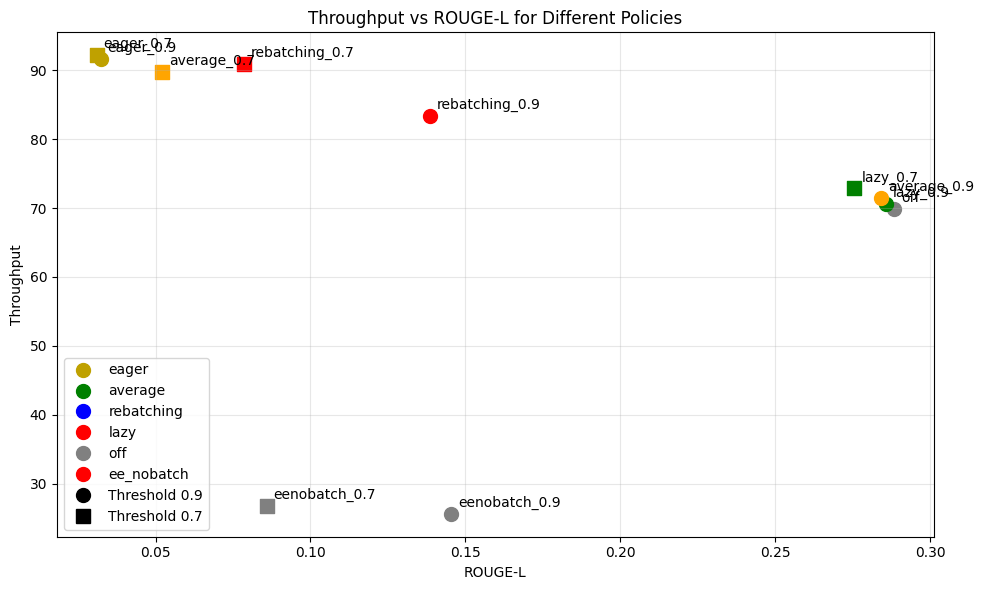

In [10]:
policies = ["eenobatch_0.9", "eenobatch_0.7", "off","eager_0.9", "lazy_0.9", "average_0.9", "rebatching_0.9", "eager_0.7", "lazy_0.7", "average_0.7", "rebatching_0.7"]
throughputs = []
rouge_scores = []
tpot = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []


ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.values[0])
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_conf07_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.values[0])
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

for policy in policies[2:7]:
    if "_" in policy:
        policy, threshold = policy.split('_')
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])

for policy in policies[7:]:
    if "_" in policy:
        policy, threshold = policy.split('_')
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_conf07_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "TPOT": tpot,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})

# 06/05/2025 llama2-70b, layer=60, conf=0.9, correct rebatching


# Define color and marker maps
policy_color = {
    'eager': '#bfa100',
    'average': 'orange',
    'rebatching': 'red',
    'lazy': 'green',
    'off': 'gray',
    'ee_nobatch': 'red'

}
threshold_marker = {
    '0.9': 'o',   # circle
    '0.7': 's',   # square
}

plt.figure(figsize=(10, 6))

# Plot each point with the correct color and marker
for i, row in df.iterrows():
    policy_full = row['policy']
    # Parse policy and threshold
    if '_' in policy_full:
        policy, threshold = policy_full.split('_')
    else:
        policy, threshold = policy_full, ''
    color = policy_color.get(policy, 'gray')
    marker = threshold_marker.get(threshold, 'o')
    plt.scatter(row['ROUGE-L'], row['throughput'], color=color, marker=marker, s=100)
    plt.annotate(policy_full, (row['ROUGE-L'], row['throughput']),
                 textcoords="offset points", xytext=(5, 5), ha='left')

# Create custom legend
legend_elements = [
    mlines.Line2D([], [], color='#bfa100', marker='o', linestyle='None', markersize=10, label='eager'),
    mlines.Line2D([], [], color='green', marker='o', linestyle='None', markersize=10, label='average'),
    mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=10, label='rebatching'),
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='lazy'),
    mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=10, label='off'),
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='ee_nobatch'),
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Threshold 0.9'),
    mlines.Line2D([], [], color='black', marker='s', linestyle='None', markersize=10, label='Threshold 0.7')

]
plt.legend(handles=legend_elements, loc='best', fontsize=10)

plt.xlabel("ROUGE-L")
plt.ylabel("Throughput")
plt.title("Throughput vs ROUGE-L for Different Policies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/throughput_vs_rougeL_req_100_batch_4_conf_0907.png")
plt.show()



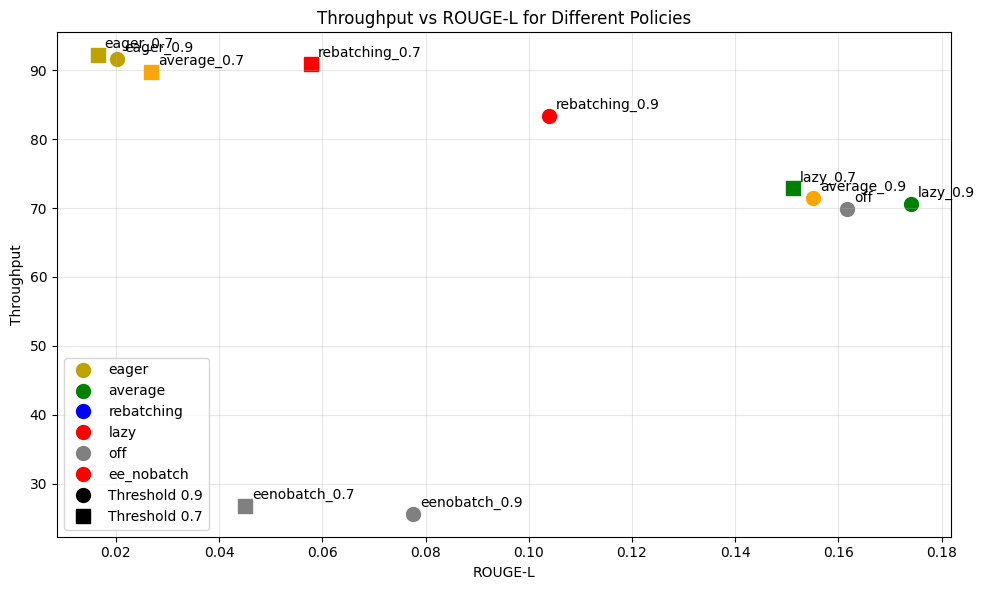

In [6]:
policies = ["eenobatch_0.9", "eenobatch_0.7", "off","eager_0.9", "lazy_0.9", "average_0.9", "rebatching_0.9", "eager_0.7", "lazy_0.7", "average_0.7", "rebatching_0.7"]
throughputs = []
rouge_scores = []
tpot = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []


ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_summaries, ee_df.output)
throughputs.append(ee_df.throughput.values[0])
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_conf07_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_summaries, ee_df.output)
throughputs.append(ee_df.throughput.values[0])
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

for policy in policies[2:7]:
    if "_" in policy:
        policy, threshold = policy.split('_')
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_summaries, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])

for policy in policies[7:]:
    if "_" in policy:
        policy, threshold = policy.split('_')
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_conf07_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_summaries, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "TPOT": tpot,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})

# 06/05/2025 llama2-70b, layer=60, conf=0.9, correct rebatching


# Define color and marker maps
policy_color = {
    'eager': '#bfa100',
    'average': 'orange',
    'rebatching': 'red',
    'lazy': 'green',
    'off': 'gray',
    'ee_nobatch': 'red'

}
threshold_marker = {
    '0.9': 'o',   # circle
    '0.7': 's',   # square
}

plt.figure(figsize=(10, 6))

# Plot each point with the correct color and marker
for i, row in df.iterrows():
    policy_full = row['policy']
    # Parse policy and threshold
    if '_' in policy_full:
        policy, threshold = policy_full.split('_')
    else:
        policy, threshold = policy_full, ''
    color = policy_color.get(policy, 'gray')
    marker = threshold_marker.get(threshold, 'o')
    plt.scatter(row['ROUGE-L'], row['throughput'], color=color, marker=marker, s=100)
    plt.annotate(policy_full, (row['ROUGE-L'], row['throughput']),
                 textcoords="offset points", xytext=(5, 5), ha='left')

# Create custom legend
legend_elements = [
    mlines.Line2D([], [], color='#bfa100', marker='o', linestyle='None', markersize=10, label='eager'),
    mlines.Line2D([], [], color='green', marker='o', linestyle='None', markersize=10, label='average'),
    mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=10, label='rebatching'),
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='lazy'),
    mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=10, label='off'),
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='ee_nobatch'),
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Threshold 0.9'),
    mlines.Line2D([], [], color='black', marker='s', linestyle='None', markersize=10, label='Threshold 0.7')

]
plt.legend(handles=legend_elements, loc='best', fontsize=10)

plt.xlabel("ROUGE-L")
plt.ylabel("Throughput")
plt.title("Throughput vs ROUGE-L for Different Policies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/throughput_vs_rougeL_req_100_batch_4_conf_0907_v2.png")
plt.show()



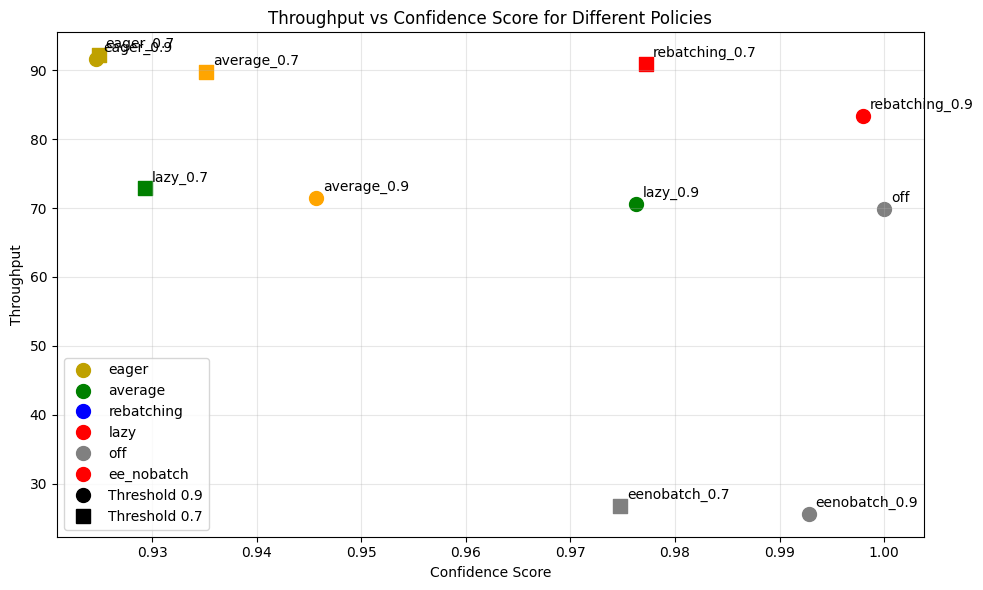

,policy,throughput,TPOT,ROUGE-L,num_ee_tokens,num_no_ee_tokens,avg_conf_score,avg_conf_score_ee
0,eenobatch_0.9,25.624084,0.038036,0.145489,28113,10200,0.897572,0.992792
1,eenobatch_0.7,26.713368,0.036491,0.085820,39809,5653,0.923920,0.974722
2,off,69.853830,0.013548,0.288385,0,1,1.000000,1.000000
3,eager_0.9,91.616374,0.010437,0.032302,25184,417,0.914289,0.924643
4,lazy_0.9,70.565332,0.013396,0.285711,180,15293,0.737211,0.976262
5,average_0.9,71.455931,0.013310,0.284112,680,17389,0.724594,0.945703
6,rebatching_0.9,83.342652,0.011282,0.138450,4338,15926,0.506057,0.997954
7,eager_0.7,92.177140,0.010342,0.031023,25492,109,0.920742,0.924860
8,lazy_0.7,72.858146,0.013015,0.275629,912,16219,0.725260,0.929299
9,average_0.7,89.749982,0.010597,0.051990,22918,2049,0.909837,0.935163


In [15]:
policies = ["eenobatch_0.9", "eenobatch_0.7", "off","eager_0.9", "lazy_0.9", "average_0.9", "rebatching_0.9", "eager_0.7", "lazy_0.7", "average_0.7", "rebatching_0.7"]
throughputs = []
rouge_scores = []
tpot = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []


ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.values[0])
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_conf07_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.values[0])
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

for policy in policies[2:7]:
    if "_" in policy:
        policy, threshold = policy.split('_')
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    if policy == "off":
        avg_conf_score.append(1)
        avg_conf_score_ee.append(1)
    else:
        avg_conf_score.append(df.avg_conf_score.values[0])
        avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])

for policy in policies[7:]:
    if "_" in policy:
        policy, threshold = policy.split('_')
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_100_batch_4_conf07_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "TPOT": tpot,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})

# 06/05/2025 llama2-70b, layer=60, conf=0.9, correct rebatching


# Define color and marker maps
policy_color = {
    'eager': '#bfa100',
    'average': 'orange',
    'rebatching': 'red',
    'lazy': 'green',
    'off': 'gray',
    'ee_nobatch': 'red'

}
threshold_marker = {
    '0.9': 'o',   # circle
    '0.7': 's',   # square
}

plt.figure(figsize=(10, 6))

# Plot each point with the correct color and marker
for i, row in df.iterrows():
    policy_full = row['policy']
    # Parse policy and threshold
    if '_' in policy_full:
        policy, threshold = policy_full.split('_')
    else:
        policy, threshold = policy_full, ''
    color = policy_color.get(policy, 'gray')
    marker = threshold_marker.get(threshold, 'o')
    plt.scatter(row['avg_conf_score_ee'], row['throughput'], color=color, marker=marker, s=100)
    plt.annotate(policy_full, (row['avg_conf_score_ee'], row['throughput']),
                 textcoords="offset points", xytext=(5, 5), ha='left')

# Create custom legend
legend_elements = [
    mlines.Line2D([], [], color='#bfa100', marker='o', linestyle='None', markersize=10, label='eager'),
    mlines.Line2D([], [], color='green', marker='o', linestyle='None', markersize=10, label='average'),
    mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=10, label='rebatching'),
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='lazy'),
    mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=10, label='off'),
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='ee_nobatch'),
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='Threshold 0.9'),
    mlines.Line2D([], [], color='black', marker='s', linestyle='None', markersize=10, label='Threshold 0.7')

]
plt.legend(handles=legend_elements, loc='best', fontsize=10)

plt.xlabel("Confidence Score")
plt.ylabel("Throughput")
plt.title("Throughput vs Confidence Score for Different Policies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/throughput_vs_confidence_req_100_batch_4_conf_0907.png")
plt.show()
df



In [6]:
policies = ["off","eager","average", "lazy","rebatching"]
throughputs = []
rouge_scores = []
tpot = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []


for policy in policies:
    df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_500_batch_8_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "TPOT": tpot,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})
df
# 06/05/2025 llama2-70b, layer=60, conf=0.9, correct rebatching

,policy,throughput,TPOT,ROUGE-L,num_ee_tokens,num_no_ee_tokens,avg_conf_score,avg_conf_score_ee
0,off,118.642560,0.007572,0.276395,0,1,0.740042,0.000000
1,eager,145.315071,0.006128,0.039479,63654,119,0.890012,0.895000
2,average,118.765437,0.007549,0.273507,316,56356,0.737785,0.927055
3,lazy,120.825451,0.007428,0.276377,21,57369,0.740114,0.973736
4,rebatching,140.017436,0.006222,0.096580,22404,36462,0.493816,0.987816


In [10]:
# No ee batch1

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(21.612178278667827)] [0.29157343311008743] [np.int64(0)] [np.int64(1)] [np.float64(0.774136109742263)] [np.float64(0.0)]


In [7]:
# ee batch1 layer=60 conf=0.9

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(25.914047819081084)] [0.16337160303943804] [np.int64(4763)] [np.int64(1512)] [np.float64(0.9143799224393138)] [np.float64(0.991260781249103)]


In [17]:
# ee batch1 layer=60 conf=0.99

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(23.59758060594299)] [0.2648997506627636] [np.int64(2128)] [np.int64(3455)] [np.float64(0.832821910077708)] [np.float64(0.9987623090470644)]


In [ ]:
# ee batch1 layer=70 conf=0.9

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(22.338862680347017)] [0.19982707037497188] [np.int64(1755)] [np.int64(3928)] [np.float64(0.7125145872798103)] [np.float64(0.9780423586524788)]


In [4]:
# ee batch1 layer=70 conf=0.99

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(21.727027303448047)] [0.25193333578740595] [np.int64(638)] [np.int64(4064)] [np.float64(0.7133639960742507)] [np.float64(0.9974248556881488)]


In [12]:
# ee batch1 layer=75 conf=0.9

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(22.01250905728256)] [0.25569117703886557] [np.int64(1818)] [np.int64(3210)] [np.float64(0.7180029574256853)] [np.float64(0.977161217050584)]


In [5]:
# ee batch1 layer=75 conf=0.9

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(21.593651261684172)] [0.28654767752356214] [np.int64(924)] [np.int64(3591)] [np.float64(0.7362343212269185)] [np.float64(0.9973302993810538)]


In [16]:
# ee batch1 layer=76 conf=0.9

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(22.011870237564956)] [0.2589751444458408] [np.int64(1968)] [np.int64(3017)] [np.float64(0.7251565490806882)] [np.float64(0.9778010903638068)]


In [14]:
# ee batch1 layer=77 conf=0.9

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(21.801940985661144)] [0.3035184657043253] [np.int64(1453)] [np.int64(1323)] [np.float64(0.7825798724306504)] [np.float64(0.9816564859723684)]


In [13]:
# ee batch1 layer=78 conf=0.9

throughputs = []
rouge_scores = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []

ee_df = pd.read_csv(f"/workspace/xutingl/vattention-ee/outputs_70b/req_20_batch_4_csv/ee_batch1.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

print(throughputs, rouge_scores, num_ee_tokens, num_no_ee_tokens, avg_conf_score, avg_conf_score_ee)

[np.float64(21.872932199163763)] [0.2925876789363389] [np.int64(2371)] [np.int64(1569)] [np.float64(0.803737917919221)] [np.float64(0.9846866629084472)]
